In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, StackingRegressor, BaggingRegressor, VotingRegressor, BaggingClassifier, RandomForestClassifier, 
                              StackingClassifier, VotingClassifier)
from tqdm.auto import tqdm
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import root_mean_squared_error, classification_report, confusion_matrix, accuracy_score, make_scorer, precision_score, f1_score
import joblib
from sklearn.pipeline import Pipeline

import requests
import time
import os
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor
import re
import seaborn as sns
import matplotlib.pyplot as plt

## Preprocessing

In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('data/epi_r.csv')

In [4]:
df

,title,rating,calories,protein,fat,sodium,#cakeweek,#wasteless,22-minute meals,3-ingredient recipes,...,yellow squash,yogurt,yonkers,yuca,zucchini,cookbooks,leftovers,snack,snack week,turkey
0,"Lentil, Apple, and Turkey Wrap",2.500,426.0,30.0,7.0,559.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Boudin Blanc Terrine with Red Onion Confit,4.375,403.0,18.0,23.0,1439.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Potato and Fennel Soup Hodge,3.750,165.0,6.0,7.0,165.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Mahi-Mahi in Tomato Olive Sauce,5.000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Spinach Noodle Casserole,3.125,547.0,20.0,32.0,452.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20047,Parmesan Puffs,3.125,28.0,2.0,2.0,64.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20048,Artichoke and Parmesan Risotto,4.375,671.0,22.0,28.0,583.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20049,Turkey Cream Puff Pie,4.375,563.0,31.0,38.0,652.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20050,Snapper on Angel Hair with Citrus Cream,4.375,631.0,45.0,24.0,517.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
ingredients = [
    'almond', 'amaretto', 'anchovy', 'anise', 'apple', 'apple juice', 'apricot',
    'artichoke', 'arugula', 'asian pear', 'asparagus', 'avocado', 'bacon',
    'banana', 'barley', 'basil', 'bass', 'bean', 'beef', 'beef rib',
    'beef shank', 'beef tenderloin', 'beer', 'beet', 'bell pepper', 'berry',
    'biscuit', 'bitters', 'blackberry', 'blue cheese', 'blueberry', 'bok choy',
    'bourbon', 'bran', 'brandy', 'bread', 'breadcrumbs', 'brie', 'broccoli',
    'broccoli rabe', 'brisket', 'brown rice', 'brownie', 'brussel sprout',
    'bulgur', 'butter', 'buttermilk', 'butternut squash', 'cabbage', 'calvados',
    'campari', 'candy', 'cantaloupe', 'capers', 'caraway', 'cardamom', 'carrot',
    'cashew', 'cauliflower', 'caviar', 'celery', 'chambord', 'champagne',
    'chard', 'chartreuse', 'cheddar', 'cheese', 'cherry', 'chestnut', 'chicken',
    'chickpea', 'chile', 'chile pepper', 'chili', 'chive', 'chocolate',
    'cilantro', 'cinnamon', 'citrus', 'clam', 'clove', 'coconut', 'cod',
    'coffee', 'cognac/armagnac', 'collard greens', 'condiment', 'cookie',
    'cookies', 'coriander', 'corn', 'cornmeal', 'cottage cheese', 'couscous',
    'crab', 'cranberry', 'cranberry sauce', 'cream cheese', 'créme de cacao',
    'crêpe', 'cucumber', 'cumin', 'cupcake', 'currant', 'curry', 'custard',
    'dairy', 'date', 'dill', 'dried fruit', 'drink', 'drinks', 'duck', 'eau de vie',
    'egg', 'egg nog', 'eggplant', 'endive', 'escarole', 'fennel', 'feta', 'fig',
    'fish', 'flat bread', 'fontina', 'fortified wine', 'frangelico', 'frittata',
    'fritter', 'frozen dessert', 'fruit juice', 'game', 'garlic', 'gin',
    'ginger', 'goat cheese', 'goose', 'gouda', 'grains', 'grand marnier',
    'granola', 'grape', 'grapefruit', 'grappa', 'green bean', 'green onion/scallion',
    'ground beef', 'ground lamb', 'guava', 'halibut', 'ham', 'hamburger',
    'hazelnut', 'herb', 'hominy/cornmeal/masa', 'honey', 'honeydew',
    'horseradish', 'hot drink', 'hot pepper', 'hummus', 'ice cream', 'iced coffee',
    'iced tea', 'jalapeño', 'jam or jelly', 'jerusalem artichoke', 'jícama',
    'kahlúa', 'kale', 'kirsch', 'kiwi', 'kumquat', 'lamb', 'lamb chop',
    'lamb shank', 'leafy green', 'leek', 'legume', 'lemon', 'lemon juice',
    'lemongrass', 'lentil', 'lettuce', 'lima bean', 'lime', 'lime juice',
    'lingonberry', 'liqueur', 'lobster', 'lychee', 'macadamia nut',
    'macaroni and cheese', 'mango', 'maple syrup', 'margarita', 'marinade',
    'marsala', 'marscarpone', 'marshmallow', 'martini', 'mayonnaise', 'meat',
    'meatball', 'meatloaf', 'melon', 'mezcal', 'midori', 'milk/cream', 'mint',
    'molasses', 'monterey jack', 'mozzarella', 'muffin', 'mushroom', 'mussel',
    'mustard', 'mustard greens', 'nectarine', 'noodle', 'nut', 'nutmeg', 'oat',
    'oatmeal', 'octopus', 'okra', 'olive', 'omelet', 'onion', 'orange',
    'orange juice', 'oregano', 'orzo', 'oyster', 'pancake', 'papaya', 'paprika',
    'parmesan', 'parsley', 'parsnip', 'passion fruit', 'pasta', 'pastry', 'pea',
    'peach', 'peanut', 'peanut butter', 'pear', 'pecan', 'pepper', 'pernod',
    'persimmon', 'phyllo/puff pastry dough', 'pickles', 'pie', 'pine nut',
    'pineapple', 'pistachio', 'pizza', 'plantain', 'plum', 'poblano',
    'pomegranate', 'pomegranate juice', 'poppy', 'pork', 'pork chop',
    'pork rib', 'pork tenderloin', 'port', 'pot pie', 'potato', 'potato salad',
    'poultry', 'poultry sausage', 'prosciutto', 'prune', 'pumpkin', 'punch',
    'quail', 'quiche', 'quince', 'quinoa', 'rabbit', 'rack of lamb', 'radicchio',
    'radish', 'raisin', 'raspberry', 'rhubarb', 'rice', 'ricotta', 'root vegetable',
    'rosemary', 'rosé', 'rum', 'rutabaga', 'rye', 'saffron', 'sage', 'sake',
    'salad', 'salad dressing', 'salmon', 'salsa', 'sandwich', 'sangria',
    'sardine', 'sauce', 'sausage', 'scallop', 'scotch', 'seafood', 'seed',
    'semolina', 'sesame', 'sesame oil', 'shallot', 'shellfish', 'sherry',
    'shrimp', 'smoothie', 'snapper', 'sorbet', 'sour cream',
    'sourdough', 'soy', 'soy sauce', 'sparkling wine', 'spice', 'spinach',
    'spirit', 'spritzer', 'squash', 'squid', 'steak', 'stock',
    'strawberry', 'stuffing/dressing', 'sugar snap pea', 'sweet potato/yam',
    'swiss cheese', 'swordfish', 'taco', 'tamarind', 'tangerine', 'tapioca',
    'tarragon', 'tart', 'tea', 'tequila', 'thyme', 'tilapia', 'tofu',
    'tomatillo', 'tomato', 'tortillas', 'triple sec', 'tropical fruit', 'trout',
    'tuna', 'turnip', 'vanilla', 'veal', 'vegetable', 'venison', 'vermouth',
    'vinegar', 'vodka', 'waffle', 'walnut', 'wasabi', 'watercress', 'watermelon',
    'whiskey', 'white wine', 'whole wheat', 'wild rice', 'wine', 'yellow squash',
    'yogurt', 'yuca', 'zucchini', 'wok'
]

In [6]:
X = pd.DataFrame(df[ingredients])
y = df[['rating']]

In [7]:
X.isnull().values.any()

np.False_

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## Baseline: Regression, Ensembles, Naive model

In [9]:
# Individual regressors with GridSearchCV

model_settings = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {'fit_intercept': [True, False], 'positive': [True, False]}
    },
    'DecisionTree': {
        'model': DecisionTreeRegressor(random_state=21),
        'params': {
            'max_depth': np.arange(1, 11),
            'min_samples_leaf': np.arange(1, 5)
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=21),
        'params': {
            'n_estimators': [5, 10, 50, 100],
            'max_depth': np.arange(1, 11),
            'min_samples_leaf': np.arange(1, 5)
        }
    }
}

best_models = {}
res = []

for name, config in tqdm(model_settings.items(), desc='Tuning regression models'):
    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    
    gs.fit(X_train, y_train)
    
    best_models[name] = gs.best_estimator_
    best_idx = gs.best_index_

    cv_mean = -gs.cv_results_['mean_test_score'][best_idx]
    cv_std = gs.cv_results_['std_test_score'][best_idx]
    train_rmse = root_mean_squared_error(y_train, gs.best_estimator_.predict(X_train))
    test_rmse = root_mean_squared_error(y_test, gs.best_estimator_.predict(X_test))
    
    res.append({
        'model': name,
        'best params':  gs.best_params_,
        'train rmse': round(train_rmse, 5),
        'cv mean rmse': round(cv_mean, 5),
        'cv std': round(cv_std, 5),
        'test rmse': round(test_rmse, 5)
        })

    print(f'For {name} best params: {gs.best_params_}\n\
    cv rmse (mean ± std): {cv_mean:.5f} ± {cv_std:.5f}\n\
    train rmse: {train_rmse:.5f}\n\
    test rmse: {test_rmse:.5f}')

Tuning regression models:   0%|          | 0/3 [00:00<?, ?it/s]

For LinearRegression best params: {'fit_intercept': True, 'positive': False}
    cv rmse (mean ± std): 1.28620 ± 0.02225
    train rmse: 1.23872
    test rmse: 1.25717
For DecisionTree best params: {'max_depth': np.int64(4), 'min_samples_leaf': np.int64(4)}
    cv rmse (mean ± std): 1.28982 ± 0.02622
    train rmse: 1.28176
    test rmse: 1.27130


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


For RandomForest best params: {'max_depth': np.int64(10), 'min_samples_leaf': np.int64(3), 'n_estimators': 100}
    cv rmse (mean ± std): 1.27653 ± 0.02552
    train rmse: 1.24008
    test rmse: 1.26040


In [10]:
# Regressor ensembles with GridSearchCV

base_estimators = [(n, m) for n, m in best_models.items()]

ensemble_settings = {
    'Voting': {
        'model': VotingRegressor(estimators=base_estimators),
        'params': {}
    },
    'Bagging': {
        'model': BaggingRegressor(
            estimator=best_models['LinearRegression'], random_state=21
        ),
        'params': {
            'n_estimators': [5, 10, 15, 20, 50],
            'max_samples':  [0.5, 0.8, 1.0]
        }
    },
    'Stacking': {
        'model': StackingRegressor(
            estimators=[
                ('lr', best_models['LinearRegression']),
                ('rf', best_models['RandomForest'])
            ],
            final_estimator=Ridge()
        ),
        'params': {'passthrough': [True, False]}
    }
}

for name, config in tqdm(ensemble_settings.items(), desc='Tuning regressor ensembles'):
    if config['params']:
        gs = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            scoring='neg_root_mean_squared_error',
            cv=5,
            n_jobs=-1
        )
        gs.fit(X_train, y_train)
        best_models[name] = gs.best_estimator_
        best_idx = gs.best_index_
        cv_mean = -gs.cv_results_['mean_test_score'][best_idx]
        cv_std = gs.cv_results_['std_test_score'][best_idx]
        best_params = gs.best_params_
    else:
        config['model'].fit(X_train, y_train)
        best_models[name] = config['model']
        cv_scores = cross_val_score(
            config['model'], X_train, y_train,
            scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
        )
        cv_mean = -cv_scores.mean()
        cv_std = cv_scores.std()
        best_params = 'default'

    test_rmse = root_mean_squared_error(y_test, best_models[name].predict(X_test))
    train_rmse = root_mean_squared_error(y_train, best_models[name].predict(X_train))

    res.append({
        'model': name,
        'best params': best_params,
        'train rmse': round(train_rmse, 5),
        'cv mean rmse': round(cv_mean, 5),
        'cv std': round(cv_std, 5),
        'test rmse': round(test_rmse, 5)
    })
    
    print(f'For {name} best params: {best_params}\n\
    cv rmse (mean ± std): {cv_mean:.5f} ± {cv_std:.5f}\n\
    train rmse: {train_rmse:.5f}\n\
    test rmse: {test_rmse:.5f}')

Tuning regressor ensembles:   0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


For Voting best params: default
    cv rmse (mean ± std): 1.27019 ± 0.02512
    train rmse: 1.24077
    test rmse: 1.24912


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\ensemble\_bagging.py:636: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


For Bagging best params: {'max_samples': 0.5, 'n_estimators': 50}
    cv rmse (mean ± std): 1.28238 ± 0.02600
    train rmse: 1.24096
    test rmse: 1.25527


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\ensemble\_stacking.py:1041: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


For Stacking best params: {'passthrough': False}
    cv rmse (mean ± std): 1.26835 ± 0.02449
    train rmse: 1.22825
    test rmse: 1.24663


In [11]:
# Naive

y_naive = np.full_like(y_test, y_train.mean(), dtype=float)
rmse_naive = root_mean_squared_error(y_test, y_naive)

res.append({
    'model': 'Naive',
    'best params': '-',
    'train rmse': '-',
    'cv mean rmse': '-',
    'cv std': '-',
    'test rmse': round(rmse_naive, 5)
})

In [12]:
# Results

df_results = pd.DataFrame(res).sort_values(by='test rmse')
print("\nModels evaluation:")
display(df_results)


Models evaluation:


,model,best params,train rmse,cv mean rmse,cv std,test rmse
5,Stacking,{'passthrough': False},1.22825,1.26835,0.02449,1.24663
3,Voting,default,1.24077,1.27019,0.02512,1.24912
4,Bagging,"{'max_samples': 0.5, 'n_estimators': 50}",1.24096,1.28238,0.026,1.25527
0,LinearRegression,"{'fit_intercept': True, 'positive': False}",1.23872,1.2862,0.02225,1.25717
2,RandomForest,"{'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 100}",1.24008,1.27653,0.02552,1.26040
1,DecisionTree,"{'max_depth': 4, 'min_samples_leaf': 4}",1.28176,1.28982,0.02622,1.27130
6,Naive,-,-,-,-,1.30724


### Итоги по разделу Baseline: Regression, Ensembles, Naive model

Лучший результат (Stacking) дает test rmse ≈ 1.25.

Рейтинги в этом датасете распределены от 0 до 5. В среднем модель ошибается на 1.25 баллов рейтинга. Также в сравнении с наивной моделью, rmse лучше у всех моделей. 

Это неплохой результат, для сервиса рекомендаций не близко к идеалу, так как модель может перепутать "отличное" блюдо (рейтинг 4.5) с "посредственным" (рейтинг 3.25), т.е. желательно, чтобы значение средней ошибки на границе классов (например, 3 - "посредственное" и 4 - "отличное") было близко к 0,5.

Стоит обратить внимание, что обычная Linear Regression (1.257) отстает от сложного Stacking (1.246) всего на 0.011. Это говорит о том, что зависимости в данных довольно простые (линейные), и усложнение модели почти не дает выигрыша.

По итогу, пользователю гораздо важнее знать: блюдо "отличное", "среднее" или "плохое". Поэтому далее поэкспериментируем с моделями для решения задачи классификации.

## Baseline: Classification

Опробуем разные представления таргета: 1) y = [0..5], 2) y = [bad, so-so, great], на обычных моделях и разных ансамблях - войтинг, бэггинг и стекинг.

В этой части y = [0..5]

In [13]:
y_c = y.round().astype(int)
y_c.value_counts()

rating
4         13188
5          2719
0          1836
3          1489
2           656
1           164
Name: count, dtype: int64

In [14]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_c, test_size=0.2, random_state=21, stratify=y_c)

In [15]:
# Individual models for classification with GridSearchCV for 6 target classes

model_settings_c = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=21, max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    'SVM': {
        'model': SVC(random_state=21),
        'params': {
            'kernel': ['rbf'],
            'C': [0.1, 1, 10],
            'gamma': ['scale'],
            'class_weight': [None, 'balanced']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=21),
        'params': {
            'max_depth': list(range(1, 20)),
            'class_weight': ['balanced', None],
            'criterion': ['entropy', 'gini'],
            'min_samples_leaf': [1, 5]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=21),
        'params': {
            'n_estimators': [5, 10, 50, 100],
            'max_depth': list(range(1, 20)),
            'class_weight': ['balanced', None],
            'criterion': ['entropy', 'gini']
        }
    }
}

best_models_c = {}
report_c = []

for name, config in tqdm(model_settings_c.items(), desc='Tuning classification models'):
    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    gs.fit(X_train_c, y_train_c)

    best_models_c[name] = gs.best_estimator_
    best_idx = gs.best_index_

    cv_mean = gs.cv_results_['mean_test_score'][best_idx]
    cv_std = gs.cv_results_['std_test_score'][best_idx]
    train_acc = accuracy_score(y_train_c, gs.best_estimator_.predict(X_train_c))
    test_acc = accuracy_score(y_test_c, gs.best_estimator_.predict(X_test_c))

    report_c.append({
        'model': name,
        'best params': gs.best_params_,
        'train acc': round(train_acc, 5),
        'cv mean acc': round(cv_mean, 5),
        'cv std': round(cv_std, 5),
        'test acc': round(test_acc, 5)
    })

    print(f'[{name}] best params: {gs.best_params_}\n\
    cv acc (mean ± std): {cv_mean:.5f} ± {cv_std:.5f}\n\
    train acc: {train_acc:.5f}\n\
    test acc: {test_acc:.5f}')

Tuning classification models:   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LogisticRegression] best params: {'C': 0.1}
    cv acc (mean ± std): 0.67059 ± 0.00428
    train acc: 0.67415
    test acc: 0.67240


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[SVM] best params: {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
    cv acc (mean ± std): 0.67315 ± 0.00251
    train acc: 0.70557
    test acc: 0.67689
[DecisionTree] best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1}
    cv acc (mean ± std): 0.66829 ± 0.00330
    train acc: 0.67409
    test acc: 0.66866


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[RandomForest] best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 18, 'n_estimators': 100}
    cv acc (mean ± std): 0.67022 ± 0.00257
    train acc: 0.68749
    test acc: 0.67240


In [16]:
# Ensembles on models for classification with GridSearchCV

base_estimators_c = [(n, m) for n, m in best_models_c.items()]

ensemble_settings_c = {
    'Voting': {
        'model': VotingClassifier(estimators=base_estimators_c),
        'params': {}
    },
    'Bagging': {
        'model': BaggingClassifier(
            estimator=best_models_c['SVM'], random_state=21
        ),
        'params': {
            'n_estimators': [5, 10, 15, 20, 50],
            'max_samples': [0.5, 0.8, 1.0]
        }
    },
    'Stacking': {
        'model': StackingClassifier(
            estimators=[
                ('lr', best_models_c['LogisticRegression']),
                ('rf', best_models_c['RandomForest'])
            ],
            final_estimator=LogisticRegression()
        ),
        'params': {'passthrough': [True, False]}
    }
}

for name, config in tqdm(ensemble_settings_c.items(), desc='Tuning classifier ensembles'):
    if config['params']:
        gs = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )
        gs.fit(X_train_c, y_train_c)
        best_models_c[name] = gs.best_estimator_
        best_idx = gs.best_index_
        cv_mean = gs.cv_results_['mean_test_score'][best_idx]
        cv_std = gs.cv_results_['std_test_score'][best_idx]
        best_params = gs.best_params_
    else:
        config['model'].fit(X_train_c, y_train_c)
        best_models_c[name] = config['model']
        cv_scores = cross_val_score(
            config['model'], X_train_c, y_train_c,
            scoring='accuracy', cv=5, n_jobs=-1
        )
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        best_params = 'default'

    train_acc = accuracy_score(y_train_c, best_models_c[name].predict(X_train_c))
    test_acc = accuracy_score(y_test_c, best_models_c[name].predict(X_test_c))

    report_c.append({
        'model': name,
        'best params': best_params,
        'train acc': round(train_acc, 5),
        'cv mean acc': round(cv_mean, 5),
        'cv std': round(cv_std, 5),
        'test acc': round(test_acc, 5)
    })

    print(f'[{name}] best params: {gs.best_params_}\n\
    cv acc (mean ± std): {cv_mean:.5f} ± {cv_std:.5f}\n\
    train acc: {train_acc:.5f}\n\
    test acc: {test_acc:.5f}')

Tuning classifier ensembles:   0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[Voting] best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 18, 'n_estimators': 100}
    cv acc (mean ± std): 0.67228 ± 0.00242
    train acc: 0.68443
    test acc: 0.67564


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\ensemble\_bagging.py:988: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[Bagging] best params: {'max_samples': 1.0, 'n_estimators': 15}
    cv acc (mean ± std): 0.67490 ± 0.00257
    train acc: 0.71573
    test acc: 0.67739


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stabl

[Stacking] best params: {'passthrough': True}
    cv acc (mean ± std): 0.67315 ± 0.00351
    train acc: 0.70070
    test acc: 0.67390


In [17]:
# Naive

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_c, y_train_c)
dummy_acc = accuracy_score(y_test_c, dummy.predict(X_test_c))

report_c.append({
    'model': 'Naive',
    'best params': '-',
    'train acc': '-',
    'cv mean acc': '-',
    'cv std': '-',
    'test acc': round(dummy_acc, 5)
})

In [18]:
# Results

df_results_c = pd.DataFrame(report_c).sort_values(by='test acc', ascending=False)
print("\nModels evaluation:")
display(df_results_c)


Models evaluation:


,model,best params,train acc,cv mean acc,cv std,test acc
5,Bagging,"{'max_samples': 1.0, 'n_estimators': 15}",0.71573,0.6749,0.00257,0.67739
1,SVM,"{'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}",0.70557,0.67315,0.00251,0.67689
4,Voting,default,0.68443,0.67228,0.00242,0.67564
6,Stacking,{'passthrough': True},0.7007,0.67315,0.00351,0.67390
0,LogisticRegression,{'C': 0.1},0.67415,0.67059,0.00428,0.67240
3,RandomForest,"{'class_weight': None, 'criterion': 'gini', 'max_depth': 18, 'n_estimators': 100}",0.68749,0.67022,0.00257,0.67240
2,DecisionTree,"{'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1}",0.67409,0.66829,0.0033,0.66866
7,Naive,-,-,-,-,0.65769


В этой части таргет y = [bad, so-so, great]

In [19]:
target_map = {
    0: 'bad', 1: 'bad',
    2: 'so-so', 3: 'so-so',
    4: 'great', 5: 'great'
}

y_cl = y_c.squeeze().map(target_map)

X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(X, y_cl, test_size=0.2, random_state=21, stratify=y_cl)

In [20]:
y_train_cl.value_counts(normalize=True).round(2)

rating
great    0.79
so-so    0.11
bad      0.10
Name: proportion, dtype: float64

Судя по выводу выше, наблюдается сильный дисбаланс классов таргета!

In [21]:
# Individual models for classification with GridSearchCV for 3 target classes

models_settings_cl = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=21, max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    'SVM': {
        'model': SVC(random_state=21),
        'params': {
            'kernel': ['rbf'],
            'C': [0.1, 1, 10],
            'gamma': ['scale'],
            'class_weight': [None, 'balanced']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=21),
        'params': {
            'max_depth': list(range(1, 20)),
            'class_weight': ['balanced', None],
            'criterion': ['entropy', 'gini'],
            'min_samples_leaf': [1, 5]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=21),
        'params': {
            'n_estimators': [5, 10, 50, 100],
            'max_depth': list(range(1, 20)),
            'class_weight': ['balanced', None],
            'criterion': ['entropy', 'gini']
        }
    }
}

best_models_cl = {}
report_cl = []

for name, config in tqdm(models_settings_cl.items(), desc='Tuning classification models with 3 classes of targets'):
    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    gs.fit(X_train_cl, y_train_cl)

    best_models_cl[name] = gs.best_estimator_
    best_idx = gs.best_index_

    cv_mean = gs.cv_results_['mean_test_score'][best_idx]
    cv_std = gs.cv_results_['std_test_score'][best_idx]
    train_acc = accuracy_score(y_train_cl, gs.best_estimator_.predict(X_train_cl))
    test_acc = accuracy_score(y_test_cl, gs.best_estimator_.predict(X_test_cl))

    report_cl.append({
        'model': name,
        'best params': gs.best_params_,
        'train acc': round(train_acc, 5),
        'cv mean acc': round(cv_mean, 5),
        'cv std': round(cv_std, 5),
        'test acc': round(test_acc, 5)
    })

    print(f'[{name}] best params: {gs.best_params_}\n\
    cv acc (mean ± std): {cv_mean:.5f} ± {cv_std:.5f}\n\
    train acc: {train_acc:.5f}\n\
    test acc: {test_acc:.5f}')

Tuning classification models with 3 classes of targets:   0%|          | 0/4 [00:00<?, ?it/s]

[LogisticRegression] best params: {'C': 1}
    cv acc (mean ± std): 0.80145 ± 0.00113
    train acc: 0.80631
    test acc: 0.80155
[SVM] best params: {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
    cv acc (mean ± std): 0.80095 ± 0.00177
    train acc: 0.81896
    test acc: 0.80454
[DecisionTree] best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}
    cv acc (mean ± std): 0.79914 ± 0.00201
    train acc: 0.79945
    test acc: 0.79830


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[RandomForest] best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 19, 'n_estimators': 100}
    cv acc (mean ± std): 0.80089 ± 0.00146
    train acc: 0.80874
    test acc: 0.80279


In [22]:
# Ensembles on models for classification with GridSearchCV for 3 classes of targets

base_estimators_cl = [(n, m) for n, m in best_models_cl.items()]

ensemble_settings_cl = {
    'Voting': {
        'model': VotingClassifier(estimators=base_estimators_cl),
        'params': {}
    },
    'Bagging': {
        'model': BaggingClassifier(
            estimator=best_models_cl['DecisionTree'],
            random_state=21
        ),
        'params': {
            'n_estimators': [5, 10, 20, 50],
            'max_samples': [0.5, 0.8, 1.0]
        }
    },
    'Stacking': {
        'model': StackingClassifier(
            estimators=[
                ('lr', best_models_cl['LogisticRegression']),
                ('rf', best_models_cl['RandomForest'])
            ],
            final_estimator=LogisticRegression(max_iter=1000)
        ),
        'params': {'passthrough': [True, False]}
    }
}

for name, config in tqdm(ensemble_settings_cl.items(), desc='Tuning classifier ensembles with 3 classes of targets'):
    if config['params']:
        gs = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )
        gs.fit(X_train_cl, y_train_cl)
        best_models_cl[name] = gs.best_estimator_
        best_idx = gs.best_index_
        cv_mean = gs.cv_results_['mean_test_score'][best_idx]
        cv_std = gs.cv_results_['std_test_score'][best_idx]
        best_params = gs.best_params_
    else:
        config['model'].fit(X_train_cl, y_train_cl)
        best_models_cl[name] = config['model']
        cv_scores = cross_val_score(
            config['model'], X_train_cl, y_train_cl,
            scoring='accuracy', cv=5, n_jobs=-1
        )
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        best_params = 'default'

    train_acc = accuracy_score(y_train_cl, best_models_cl[name].predict(X_train_cl))
    test_acc = accuracy_score(y_test_cl, best_models_cl[name].predict(X_test_cl))

    report_cl.append({
        'model': name,
        'best params': best_params,
        'train acc': round(train_acc, 5),
        'cv mean acc': round(cv_mean, 5),
        'cv std': round(cv_std, 5),
        'test acc': round(test_acc, 5)
    })

    print(f'[{name}] best params: {best_params}\n\
    cv acc (mean ± std): {cv_mean:.5f} ± {cv_std:.5f}\n\
    train acc: {train_acc:.5f}\n\
    test acc: {test_acc:.5f}')

Tuning classifier ensembles with 3 classes of targets:   0%|          | 0/3 [00:00<?, ?it/s]

[Voting] best params: default
    cv acc (mean ± std): 0.80201 ± 0.00171
    train acc: 0.80961
    test acc: 0.80379
[Bagging] best params: {'max_samples': 1.0, 'n_estimators': 5}
    cv acc (mean ± std): 0.79951 ± 0.00131
    train acc: 0.80039
    test acc: 0.79930
[Stacking] best params: {'passthrough': True}
    cv acc (mean ± std): 0.80170 ± 0.00286
    train acc: 0.81610
    test acc: 0.80180


In [23]:
# Naive

dummy_cl = DummyClassifier(strategy='most_frequent')
dummy_cl.fit(X_train_cl, y_train_cl)
dummy_acc_cl = accuracy_score(y_test_cl, dummy_cl.predict(X_test_cl))

report_cl.append({
    'model': 'Naive',
    'best params': '-',
    'train acc': '-',
    'cv mean acc': '-',
    'cv std': '-',
    'test acc': round(dummy_acc_cl, 5)
})

In [24]:
# Results

df_results_cl = pd.DataFrame(report_cl).sort_values(by='test acc', ascending=False)
print("\nModels evaluation:")
display(df_results_cl)


Models evaluation:


,model,best params,train acc,cv mean acc,cv std,test acc
1,SVM,"{'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}",0.81896,0.80095,0.00177,0.80454
4,Voting,default,0.80961,0.80201,0.00171,0.80379
3,RandomForest,"{'class_weight': None, 'criterion': 'gini', 'max_depth': 19, 'n_estimators': 100}",0.80874,0.80089,0.00146,0.80279
6,Stacking,{'passthrough': True},0.8161,0.8017,0.00286,0.80180
0,LogisticRegression,{'C': 1},0.80631,0.80145,0.00113,0.80155
5,Bagging,"{'max_samples': 1.0, 'n_estimators': 5}",0.80039,0.79951,0.00131,0.79930
2,DecisionTree,"{'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}",0.79945,0.79914,0.00201,0.79830
7,Naive,-,-,-,-,0.79332


На двух разных вариациях представления таргета мы увидели, что значение test accuracy в лучшем случае получается в районе 0,8 на SVM, Voting, Random Forest. Если сравнивать с наивной моделью, то она лишь немного хуже угадывает верный класс, судя по небольшой разнице в сотых значениях test accuracy. К тому же, мы увидели долю каждого класса таргета из трех (bad, so-so, great) и там имеется сильный дисбаланс в сторону great (79 %). В этом случае использование метрики accuracy не совсем рационально. 

В данной ситуации для нас важно, насколько хорошо модель будет находить долю конкретного класса, среди всех найденных классификатором классов, т.е. точность, поскольку будет критичным, если модель предскажет хороший рейтинг для плохого блюда, что являетя ошибкой первого рода (False Positive). Метрика, которая чувствительна к такой ошибке - Precision. Поэтому далее будем оценивать качество классификации по ней.

In [25]:
def safe_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def safe_precision(y_true, y_pred):
    return precision_score(y_true, y_pred, average='macro', zero_division=0)

f1_scorer = make_scorer(safe_f1)
precision_scorer = make_scorer(safe_precision)

In [26]:
# Individual classifiers with GridSearchCV (f1-score, precision metrics)

models_settings_pre = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=21, max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    'SVM': {
        'model': SVC(random_state=21),
        'params': {
            'kernel': ['rbf'],
            'C': [0.1, 1, 10],
            'gamma': ['scale'],
            'class_weight': [None, 'balanced']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=21),
        'params': {
            'max_depth': list(range(1, 20)),
            'class_weight': ['balanced', None],
            'criterion': ['entropy', 'gini'],
            'min_samples_leaf': [1, 5]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=21),
        'params': {
            'n_estimators': [5, 10, 50, 100],
            'max_depth': list(range(1, 20)),
            'class_weight': ['balanced', None],
            'criterion': ['entropy', 'gini']
        }
    }
}

best_models_pre = {}
report_pre = []

for name, config in tqdm(models_settings_pre.items(), desc='Tuning models (precision)'):
    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring=f1_scorer,
        n_jobs=-1
    )
    gs.fit(X_train_cl, y_train_cl)

    best_models_pre[name] = gs.best_estimator_
    best_idx = gs.best_index_

    cv_mean_f1 = gs.cv_results_['mean_test_score'][best_idx]
    cv_std_f1 = gs.cv_results_['std_test_score'][best_idx]

    train_pr = precision_score(
        y_train_cl, gs.best_estimator_.predict(X_train_cl),
        average='macro', zero_division=0
    )
    test_pr = precision_score(
        y_test_cl, gs.best_estimator_.predict(X_test_cl),
        average='macro', zero_division=0
    )

    report_pre.append({
        'model': name,
        'best params': gs.best_params_,
        'train precision': round(train_pr, 5),
        'cv mean f1':round(cv_mean_f1, 5),
        'cv std f1': round(cv_std_f1, 5),
        'test precision': round(test_pr, 5)
    })

    print(f'[{name}] best params: {gs.best_params_}\n\
    cv f1 (mean ± std): {cv_mean_f1:.5f} ± {cv_std_f1:.5f}\n\
    train precision: {train_pr:.5f}\n\
    test precision: {test_pr:.5f}')

Tuning models (precision):   0%|          | 0/4 [00:00<?, ?it/s]

[LogisticRegression] best params: {'C': 10}
    cv f1 (mean ± std): 0.39740 ± 0.01039
    train precision: 0.69880
    test precision: 0.50666
[SVM] best params: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
    cv f1 (mean ± std): 0.47059 ± 0.00715
    train precision: 0.97383
    test precision: 0.57494
[DecisionTree] best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}
    cv f1 (mean ± std): 0.42692 ± 0.01193
    train precision: 0.46693
    test precision: 0.47692


c:\Users\pavel.zubkov\Desktop\ML\s21_ds\myvenv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[RandomForest] best params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 19, 'n_estimators': 100}
    cv f1 (mean ± std): 0.47019 ± 0.00631
    train precision: 0.65098
    test precision: 0.47861


In [27]:
# Ensembles with GridSearchCV (f1-score, precision metrics)

base_estimators_pre = [(n, m) for n, m in best_models_pre.items()]

ensemble_settings_pre = {
    'Voting': {
        'model': VotingClassifier(estimators=base_estimators_pre),
        'params': {}
    },
    'Bagging': {
        'model': BaggingClassifier(
            estimator=best_models_pre['DecisionTree'], random_state=21
        ),
        'params': {
            'n_estimators': [5, 20, 50],
            'max_samples': [0.5, 1.0]
        }
    },
    'Stacking': {
        'model': StackingClassifier(
            estimators=[
                ('lr', best_models_pre['LogisticRegression']),
                ('rf', best_models_pre['RandomForest'])
            ],
            final_estimator=LogisticRegression(max_iter=1000)
        ),
        'params': {'passthrough': [True, False]}
    }
}

for name, config in tqdm(ensemble_settings_pre.items(), desc='Tuning ensembles (precision)'):
    if config['params']:
        gs = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=5,
            scoring=f1_scorer,
            n_jobs=-1
        )
        gs.fit(X_train_cl, y_train_cl)
        best_models_pre[name] = gs.best_estimator_
        best_idx = gs.best_index_
        cv_mean_f1 = gs.cv_results_['mean_test_score'][best_idx]
        cv_std_f1 = gs.cv_results_['std_test_score'][best_idx]
        best_params = gs.best_params_
    else:
        config['model'].fit(X_train_cl, y_train_cl)
        best_models_pre[name] = config['model']
        cv_scores = cross_val_score(
            config['model'], X_train_cl, y_train_cl,
            scoring=f1_scorer, cv=5, n_jobs=-1
        )
        cv_mean_f1 = cv_scores.mean()
        cv_std_f1 = cv_scores.std()
        best_params = 'default'

    train_pr = precision_score(
        y_train_cl, best_models_pre[name].predict(X_train_cl),
        average='macro', zero_division=0
    )
    test_pr = precision_score(
        y_test_cl, best_models_pre[name].predict(X_test_cl),
        average='macro', zero_division=0
    )

    report_pre.append({
        'model': name,
        'best params': best_params,
        'train precision': round(train_pr, 5),
        'cv mean f1': round(cv_mean_f1, 5),
        'cv std f1': round(cv_std_f1, 5),
        'test precision': round(test_pr, 5)
    })

    print(f'[{name}] best params: {best_params}\n\
    cv f1 (mean ± std): {cv_mean_f1:.5f} ± {cv_std_f1:.5f}\n\
    train precision: {train_pr:.5f}\n\
    test precision: {test_pr:.5f}')

Tuning ensembles (precision):   0%|          | 0/3 [00:00<?, ?it/s]

[Voting] best params: default
    cv f1 (mean ± std): 0.43947 ± 0.00846
    train precision: 0.79934
    test precision: 0.62033
[Bagging] best params: {'max_samples': 0.5, 'n_estimators': 50}
    cv f1 (mean ± std): 0.43054 ± 0.01561
    train precision: 0.43740
    test precision: 0.43568
[Stacking] best params: {'passthrough': False}
    cv f1 (mean ± std): 0.39001 ± 0.00429
    train precision: 0.87662
    test precision: 0.48968


In [28]:
# Naive

dummy_pre = DummyClassifier(strategy='most_frequent')
dummy_pre.fit(X_train_cl, y_train_cl)
dummy_pr = precision_score(
    y_test_cl, dummy_pre.predict(X_test_cl),
    average='macro', zero_division=0
)

report_pre.append({
    'model': 'Naive',
    'best params': '-',
    'train precision':'-',
    'cv mean f1': '-',
    'cv std f1': '-',
    'test precision': round(dummy_pr, 5)
})

In [29]:
# Results

df_results_pre = pd.DataFrame(report_pre).sort_values(by='test precision', ascending=False)
print("\nModels evaluation:")
df_results_pre


Models evaluation:


,model,best params,train precision,cv mean f1,cv std f1,test precision
4,Voting,default,0.79934,0.43947,0.00846,0.62033
1,SVM,"{'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}",0.97383,0.47059,0.00715,0.57494
0,LogisticRegression,{'C': 10},0.6988,0.3974,0.01039,0.50666
6,Stacking,{'passthrough': False},0.87662,0.39001,0.00429,0.48968
3,RandomForest,"{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 19, 'n_estimators': 100}",0.65098,0.47019,0.00631,0.47861
2,DecisionTree,"{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}",0.46693,0.42692,0.01193,0.47692
5,Bagging,"{'max_samples': 0.5, 'n_estimators': 50}",0.4374,0.43054,0.01561,0.43568
7,Naive,-,-,-,-,0.26444


In [30]:
pipeline = Pipeline([
    ('model', best_models_pre['Voting'])
])
pipeline.fit(X_train_cl, y_train_cl)
joblib.dump(pipeline, 'data/best_model_voting.pkl')

model = joblib.load('data/best_model_voting.pkl')
print(model)

y_check = model.predict(X_test_cl)
print(f"Macro precision: {round(precision_score(y_test_cl, y_check, average='macro', zero_division=0), 5)}")

report = classification_report(y_test_cl, y_check, output_dict=True)
print(f"Precision для класса 'great': {round(report['great']['precision'], 5)}")

Pipeline(steps=[('model',
                 VotingClassifier(estimators=[('LogisticRegression',
                                               LogisticRegression(C=10,
                                                                  max_iter=1000,
                                                                  random_state=21)),
                                              ('SVM',
                                               SVC(C=10, random_state=21)),
                                              ('DecisionTree',
                                               DecisionTreeClassifier(class_weight='balanced',
                                                                      max_depth=5,
                                                                      min_samples_leaf=5,
                                                                      random_state=21)),
                                              ('RandomForest',
                                               RandomF

## Выводы

При первоначальном сравнении по accuracy был выявлен сильный дисбаланс классов: наивный классификатор (предсказывающий всегда самый частый класс) показал точность ~79%. Это делает метрику accuracy неинформативной, так как она не отражает реальную способность модели различать "плохие" и "средние" рецепты.

В качестве основной метрики для подбора параметров был выбран f1-score (macro), а для финальной оценки — precision (macro). В рамках кулинарного приложения наиболее критичной ошибкой является False Positive для класса great (предсказание высокого рейтинга для плохого блюда). Высокий Precision гарантирует, что если система порекомендует рецепт как "отличный", он с высокой вероятностью оправдает ожидания пользователя.

В ходе исследования были протестированы одиночные классификаторы (LR, SVM, DT, RF) и ансамбли (Bagging, Stacking, Voting).
 - Одиночные модели: показали высокую склонность к переобучению (особенно SVM, где разрыв между train и test precision составил более 35%).
 - Ансамбли: продемонстрировали лучшую обобщающую способность. Voting Classifier стал лидером, показав Test Precision = 0.62. Это в 2.4 раза выше, чем у наивного классификатора (0.264), что подтверждает адекватность модели.
 
Регрессия или Классификация?

Сравнение результатов показало следующее: регрессия (лучший результат Stacking RMSE: 1.247) дает слишком высокую неопределенность (при ошибке в 1.25 балла невозможно гарантированно отделить "хороший" рецепт от "посредственного"), в то время как классификация позволяет более жестче фильтровать. Точность в 62% при работе с тремя несбалансированными классами является качественным результатом для данной задачи.

Таким образом, выбрана модель Voting Classifier, обученная на текстовых категориях. Она обеспечивает наилучший баланс между точностью предсказания и стабильностью на новых данных.

## Parsing and calculating Daily Value of nutrients for ingredients

In [31]:
API_KEY = 'wxhqe4ZCTaoJA9tJJwzAxvkHAHxI4b5Ji7uGiMWE'
BASE_URL = 'https://api.nal.usda.gov/fdc/v1/foods/search'
OUTPUT_FILE = 'data/ingredients_nutrition.csv'
CHECKPOINT_STEP = 50

ingredient_cols = X.columns.to_list()
dv_mapping_with_ids = {
    'Vitamin A': {'dv': 900, 'nutrient_id': 1104},
    'Vitamin C': {'dv': 90, 'nutrient_id': 1162},
    'Calcium': {'dv': 1300, 'nutrient_id': 1087},
    'Iron': {'dv': 18, 'nutrient_id': 1089},
    'Vitamin D': {'dv': 20, 'nutrient_id': 1110},
    'Vitamin E': {'dv': 15, 'nutrient_id': 1109},
    'Vitamin K': {'dv': 120, 'nutrient_id': 1185},
    'Thiamin': {'dv': 1.2, 'nutrient_id': 1165},
    'Riboflavin': {'dv': 1.3, 'nutrient_id': 1166},
    'Niacin': {'dv': 16, 'nutrient_id': 1167},
    'Vitamin B6': {'dv': 1.7, 'nutrient_id': 1175},
    'Folate': {'dv': 400, 'nutrient_id': 1177},
    'Vitamin B12': {'dv': 2.4, 'nutrient_id': 1178},
    'Biotin': {'dv': 30, 'nutrient_id': 1176},
    'Pantothenic acid': {'dv': 5, 'nutrient_id': 1170},
    'Phosphorus': {'dv': 1250, 'nutrient_id': 1091},
    'Iodine': {'dv': 150, 'nutrient_id': 1094},
    'Magnesium': {'dv': 420, 'nutrient_id': 1090},
    'Zinc': {'dv': 11, 'nutrient_id': 1095},
    'Selenium': {'dv': 55, 'nutrient_id': 1103},
    'Copper': {'dv': 0.9, 'nutrient_id': 1098},
    'Manganese': {'dv': 2.3, 'nutrient_id': 1101},
    'Chromium': {'dv': 35, 'nutrient_id': 1096},
    'Molybdenum': {'dv': 45, 'nutrient_id': 1102},
    'Chloride': {'dv': 2300, 'nutrient_id': 1088},
    'Potassium': {'dv': 4700, 'nutrient_id': 1092},
    'Choline': {'dv': 550, 'nutrient_id': 1180},
    'Fat': {'dv': 78, 'nutrient_id': 1004},
    'Saturated fat': {'dv': 20, 'nutrient_id': 1258},
    'Cholesterol': {'dv': 300, 'nutrient_id': 1253},
    'Total carbohydrates': {'dv': 275, 'nutrient_id': 1005},
    'Sodium': {'dv': 2300, 'nutrient_id': 1093},
    'Dietary Fiber': {'dv': 28, 'nutrient_id': 1079},
    'Protein': {'dv': 50, 'nutrient_id': 1003},
    'Added sugars': {'dv': 50, 'nutrient_id': 1239}
}

if os.path.exists(OUTPUT_FILE):
    processed_df = pd.read_csv(OUTPUT_FILE)
    nutr_res = processed_df.to_dict('records')
    processed_ingredients = set(processed_df['ingredient'].tolist())
    print(f"Find saves. Already processed: {len(processed_ingredients)}")
else:
    nutr_res = []
    processed_ingredients = set()

for i, ingr in enumerate(tqdm(ingredient_cols, desc='Processing ingredients')):
    if ingr in processed_ingredients:
        continue
    try:
        clean_query = ingr.replace('/', ' ').replace(',', ' ').strip()

        params = {
            'api_key': API_KEY,
            'query': clean_query,
            'pageSize': 1,
            'dataType': 'Foundation,SR Legacy,Branded'
        }

        response = requests.get(BASE_URL, params=params)

        if response.status_code != 200:
            print(f"\nAPI Error {response.status_code} for '{ingr}': {response.text}")
            if response.status_code == 429:
                time.sleep(10)
            continue

        data = response.json()

        if data.get('foods') and len(data['foods']) > 0:
            food = data['foods'][0]
            nutrients = {n['nutrientId']: n['value'] for n in food.get('foodNutrients', [])}
            row = {'ingredient': ingr}

            for name, info in dv_mapping_with_ids.items():
                nid = info['nutrient_id']
                dv = info['dv']
                val = nutrients.get(nid, 0)
                row[f'{name}_DV%'] = round((val / dv) * 100, 2)

            nutr_res.append(row)
            processed_ingredients.add(ingr)

        if (i + 1) % CHECKPOINT_STEP == 0:
            pd.DataFrame(nutr_res).to_csv(OUTPUT_FILE, index=False)
            print(f"Checkpoint: saved {len(processed_ingredients)} ingredients to '{OUTPUT_FILE}'")
        time.sleep(2)

    except Exception as e:
        print(f"\nCritical error with '{ingr}': {e}")
        continue

df_nutr = pd.DataFrame(nutr_res)
df_nutr.to_csv(OUTPUT_FILE, index=False)
print(f"Finished processing. Total ingredients: {len(processed_ingredients)}. Data saved to '{OUTPUT_FILE}'")

Find saves. Already processed: 379


Processing ingredients:   0%|          | 0/384 [00:00<?, ?it/s]


API Error 403 for 'campari': <html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
</body>
</html>


API Error 403 for 'chartreuse': <html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
</body>
</html>


API Error 403 for 'grappa': <html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
</body>
</html>


API Error 403 for 'jícama': <html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
</body>
</html>


API Error 403 for 'kahlúa': <html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
</body>
</html>


API Error 403 for 'marscarpone': <html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
</body>
</html>


API Error 403 for 'rosé': <html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
</body>
</html>

In [32]:
original_count = len(X.columns)
collected_count = len(df_nutr)

print(f"Исходных ингредиентов: {original_count}")
print(f"Собрано данных: {collected_count}")

if original_count > collected_count:
    print(f"{original_count - collected_count} ингредиентов были пропущены (ошибки API или нет совпадений).")

Исходных ингредиентов: 384
Собрано данных: 379
5 ингредиентов были пропущены (ошибки API или нет совпадений).


In [ ]:
nutrient_cols = [c for c in df_nutr.columns if '_DV%' in c]

empty_rows = df_nutr[df_nutr[nutrient_cols].sum(axis=1) == 0]

print(f"Ингредиентов с нулевыми данными: {len(empty_rows)}")
if not empty_rows.empty:
    print("Примеры пустых ингредиентов:")
    print(empty_rows['ingredient'])

Ингредиентов с нулевыми данными: 4
Примеры пустых ингредиентов:
344    breadcrumbs
363         midori
372         sherry
375       spritzer
Name: ingredient, dtype: object


In [34]:
pd.options.display.max_columns = None
display(df_nutr[nutrient_cols].describe())

,Vitamin A_DV%,Vitamin C_DV%,Calcium_DV%,Iron_DV%,Vitamin D_DV%,Vitamin E_DV%,Vitamin K_DV%,Thiamin_DV%,Riboflavin_DV%,Niacin_DV%,Vitamin B6_DV%,Folate_DV%,Vitamin B12_DV%,Biotin_DV%,Pantothenic acid_DV%,Phosphorus_DV%,Iodine_DV%,Magnesium_DV%,Zinc_DV%,Selenium_DV%,Copper_DV%,Manganese_DV%,Chromium_DV%,Molybdenum_DV%,Chloride_DV%,Potassium_DV%,Choline_DV%,Fat_DV%,Saturated fat_DV%,Cholesterol_DV%,Total carbohydrates_DV%,Sodium_DV%,Dietary Fiber_DV%,Protein_DV%,Added sugars_DV%
count,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.0,379.000000,379.000000,379.000000,379.000000,379.000000,379.0,379.000000,379.0,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.0
mean,151.028813,12.143747,7.468839,13.041266,179.411873,7.279683,22.611266,10.689077,11.853404,10.140185,10.438522,7.120976,22.795752,1.589288,6.442586,8.927309,0.0,9.195778,9.230317,13.232718,22.166807,33.880765,0.0,0.541187,0.0,6.169156,2.481293,14.141636,17.231873,9.382401,8.017757,14.176227,10.430264,14.221055,0.0
std,818.489054,28.333874,16.338320,33.877927,2588.682163,25.592331,117.891362,25.647710,23.648163,16.501790,29.882472,14.634497,131.876636,19.192322,12.549237,11.376197,0.0,15.981467,13.249377,24.123523,50.126400,169.511509,0.0,7.615384,0.0,8.351702,6.298496,25.850550,38.594926,26.896604,9.370008,33.213262,23.072793,15.856408,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.200000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.620000,1.110000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.840000,0.0,1.430000,0.595000,0.000000,2.220000,0.080000,0.0,0.000000,0.0,1.640000,0.000000,0.260000,0.050000,0.000000,1.125000,0.170000,0.000000,1.610000,0.0
50%,2.110000,0.000000,1.770000,3.890000,0.000000,0.800000,0.000000,3.080000,4.620000,2.660000,3.240000,2.250000,0.000000,0.000000,2.700000,4.400000,0.0,4.050000,3.360000,1.450000,7.110000,2.740000,0.0,0.000000,0.0,3.870000,0.070000,2.320000,1.160000,0.000000,4.000000,1.870000,3.360000,6.540000,0.0
75%,30.725000,8.980000,6.080000,11.615000,0.000000,4.065000,2.920000,9.330000,13.925000,12.620000,9.735000,9.350000,2.500000,0.000000,8.140000,13.760000,0.0,7.860000,12.365000,17.000000,19.220000,13.370000,0.0,0.000000,0.0,7.140000,2.480000,17.820000,19.775000,6.165000,12.180000,13.975000,10.270000,23.700000,0.0
max,11111.110000,203.330000,126.920000,368.890000,50000.000000,314.670000,1425.000000,366.670000,248.460000,107.500000,347.060000,184.500000,2250.000000,292.670000,123.600000,69.600000,0.0,101.900000,76.360000,162.550000,662.220000,2613.040000,0.0,124.890000,0.0,64.260000,89.270000,128.210000,450.000000,236.670000,36.360000,256.090000,190.000000,64.000000,0.0


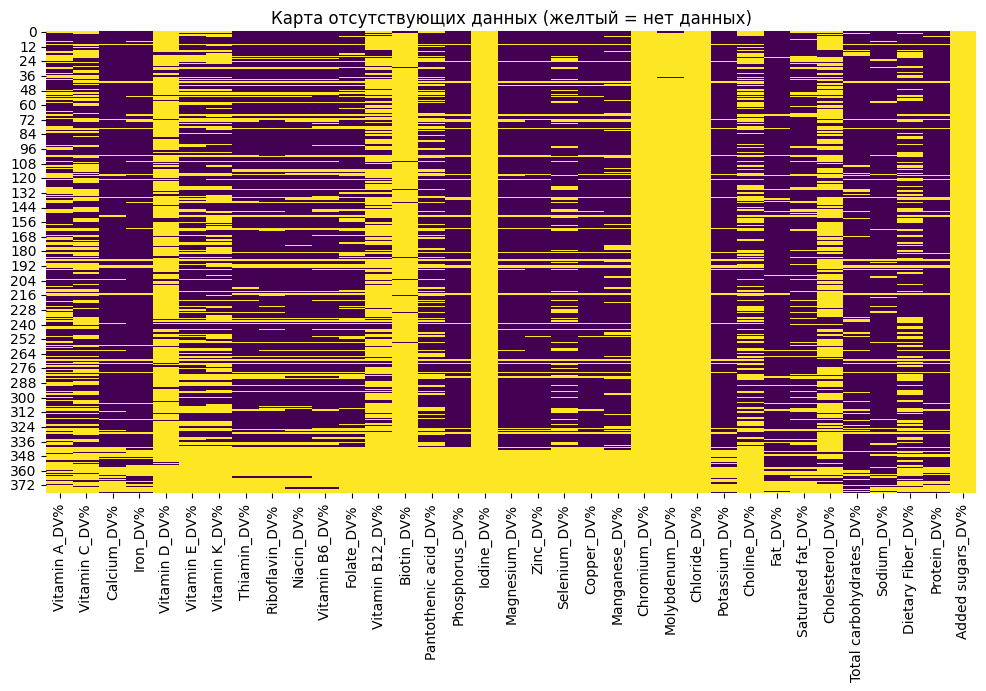

In [35]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_nutr[nutrient_cols].replace(0, pd.NA).isna(), cbar=False, cmap='viridis')
plt.title("Карта отсутствующих данных (желтый = нет данных)")
plt.show()

In [36]:
cols_to_drop = ['Chromium_DV%', 'Molybdenum_DV%', 'Chloride_DV%', 'Iodine_DV%', 'Biotin_DV%', 'Vitamin D_DV%','Added sugars_DV%']
df_nutr = df_nutr.drop(columns=[c for c in cols_to_drop if c in df_nutr.columns])

In [37]:
df_nutr = df_nutr.fillna(0)

In [38]:
missing_ingr = [ing for ing in ingredient_cols if ing not in df_nutr['ingredient'].values]
df_missing = pd.DataFrame({'ingredient': missing_ingr})
df_nutr = pd.concat([df_nutr, df_missing], ignore_index=True).fillna(0)

In [39]:
df_nutr.describe()

,Vitamin A_DV%,Vitamin C_DV%,Calcium_DV%,Iron_DV%,Vitamin E_DV%,Vitamin K_DV%,Thiamin_DV%,Riboflavin_DV%,Niacin_DV%,Vitamin B6_DV%,Folate_DV%,Vitamin B12_DV%,Pantothenic acid_DV%,Phosphorus_DV%,Magnesium_DV%,Zinc_DV%,Selenium_DV%,Copper_DV%,Manganese_DV%,Potassium_DV%,Choline_DV%,Fat_DV%,Saturated fat_DV%,Cholesterol_DV%,Total carbohydrates_DV%,Sodium_DV%,Dietary Fiber_DV%,Protein_DV%
count,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000,387.000000
mean,147.906770,11.892713,7.314444,12.771680,7.129199,22.143850,10.468114,11.608372,9.930568,10.222739,6.973773,22.324522,6.309406,8.742765,9.005685,9.039509,12.959173,21.708579,33.180388,6.041628,2.430000,13.849302,16.875659,9.188450,7.852016,13.883178,10.214651,13.927080
std,810.248638,28.092047,16.203101,33.576467,25.346964,116.707761,25.426184,23.462673,16.393669,29.608559,14.517541,130.543287,12.452386,11.329309,15.869159,13.177140,23.946554,49.704663,167.815149,8.311305,6.242901,25.660481,38.271704,26.649967,9.342494,32.929275,22.880748,15.821492
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.200000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.600000,0.940000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.720000,1.070000,0.450000,0.000000,2.000000,0.000000,1.405000,0.000000,0.240000,0.030000,0.000000,0.955000,0.130000,0.000000,1.400000
50%,1.780000,0.000000,1.620000,3.780000,0.730000,0.000000,2.830000,4.380000,2.500000,3.120000,2.000000,0.000000,2.500000,4.160000,4.050000,3.270000,1.270000,6.780000,2.610000,3.830000,0.000000,2.180000,0.990000,0.000000,3.820000,1.710000,3.210000,6.040000
75%,29.335000,8.890000,5.735000,11.085000,4.000000,2.790000,9.290000,13.500000,12.030000,9.470000,9.125000,2.080000,8.000000,13.280000,7.860000,11.955000,15.910000,18.330000,12.955000,7.040000,2.430000,16.920000,18.075000,5.835000,11.960000,13.195000,10.000000,23.600000
max,11111.110000,203.330000,126.920000,368.890000,314.670000,1425.000000,366.670000,248.460000,107.500000,347.060000,184.500000,2250.000000,123.600000,69.600000,101.900000,76.360000,162.550000,662.220000,2613.040000,64.260000,89.270000,128.210000,450.000000,236.670000,36.360000,256.090000,190.000000,64.000000


## Parsing links for recipes

In [40]:
df_main = df.copy()

In [ ]:
def title_to_key(title):
    if not isinstance(title, str):
        return ""
    
    key = title.lower().strip()
    
    key = re.sub(r'[^a-z0-9\s-]', '', key)
    
    key = re.sub(r'[\s-]+', '-', key)
    return key

def parse_single_submap(submap_url):
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        resp = requests.get(submap_url, headers=headers, timeout=15)
        if resp.status_code != 200:
            return []
        
        soup = BeautifulSoup(resp.content, 'lxml-xml')
        links = [
            loc.text for loc in soup.find_all('loc') 
            if '/recipes/food/views/' in loc.text
        ]
        return links
    
    except Exception as e:
        return []

def get_all_possible_submaps():
    index_url = "https://www.epicurious.com/sitemap.xml"
    headers = {'User-Agent': 'Mozilla/5.0'}
    resp = requests.get(index_url, headers=headers)
    soup = BeautifulSoup(resp.content, 'lxml-xml')
    
    links = [loc.text for loc in soup.find_all('loc')]
    
    manual_links = [
        "https://www.epicurious.com/sitemap-archive-1.xml",
        "https://www.epicurious.com/categories-sitemap.xml"
    ]
    
    return list(set(links + manual_links))

all_submaps = get_all_possible_submaps()
print(f"Найдено под-карт для проверки: {len(all_submaps)}")

all_recipe_links = []
with ThreadPoolExecutor(max_workers=20) as executor:
    results = list(tqdm(executor.map(parse_single_submap, all_submaps), total=len(all_submaps), desc="Парсинг архивов"))
    
for res in results:
    all_recipe_links.extend(res)

all_recipe_links = list(set(all_recipe_links))
print(f"Итого собрано прямых ссылок: {len(all_recipe_links)}")

Найдено под-карт для проверки: 1002


Парсинг архивов:   0%|          | 0/1002 [00:00<?, ?it/s]

Итого собрано прямых ссылок: 15809


In [ ]:
url_lookup = {re.sub(r'-\d+$', '', l.split('/')[-1]): l for l in all_recipe_links}

def get_final_url(row):
    title = row['title']
    title_key = title_to_key(title)
    
    if title_key in url_lookup:
        return url_lookup[title_key]
    
    return f"https://www.epicurious.com/search?q={title.replace(' ', '+')}"

df_main['url'] = df_main.apply(get_final_url, axis=1)

print(f"Прямых ссылок из Sitemap: {df_main['url'].str.contains('/views/').sum()}")
print(f"Поисковых ссылок: {df_main['url'].str.contains(r'search\?q=').sum()}")

Прямых ссылок из Sitemap: 4525
Поисковых ссылок: 15527


In [43]:
df_main

,title,rating,calories,protein,fat,sodium,#cakeweek,#wasteless,22-minute meals,3-ingredient recipes,30 days of groceries,advance prep required,alabama,alaska,alcoholic,almond,amaretto,anchovy,anise,anniversary,anthony bourdain,aperitif,appetizer,apple,apple juice,apricot,arizona,artichoke,arugula,asian pear,asparagus,aspen,atlanta,australia,avocado,back to school,backyard bbq,bacon,bake,banana,barley,basil,bass,bastille day,bean,beef,beef rib,beef shank,beef tenderloin,beer,beet,bell pepper,berry,beverly hills,birthday,biscuit,bitters,blackberry,blender,blue cheese,blueberry,boil,bok choy,bon appétit,bon app��tit,boston,bourbon,braise,bran,brandy,bread,breadcrumbs,breakfast,brie,brine,brisket,broccoli,broccoli rabe,broil,brooklyn,brown rice,brownie,brunch,brussel sprout,buffalo,buffet,bulgaria,bulgur,burrito,butter,buttermilk,butternut squash,butterscotch/caramel,cabbage,cake,california,calvados,cambridge,campari,camping,canada,candy,candy thermometer,cantaloupe,capers,caraway,cardamom,carrot,cashew,casserole/gratin,cauliflower,caviar,celery,chambord,champagne,chard,chartreuse,cheddar,cheese,cherry,chestnut,chicago,chicken,chickpea,chile,chile pepper,chili,chill,chive,chocolate,christmas,christmas eve,cilantro,cinco de mayo,cinnamon,citrus,clam,clove,cobbler/crumble,cocktail,cocktail party,coconut,cod,coffee,coffee grinder,cognac/armagnac,collard greens,colorado,columbus,condiment,condiment/spread,connecticut,cook like a diner,cookbook critic,cookie,cookies,coriander,corn,cornmeal,costa mesa,cottage cheese,couscous,crab,cranberry,cranberry sauce,cream cheese,créme de cacao,crêpe,cr��me de cacao,cuba,cucumber,cumin,cupcake,currant,curry,custard,dairy,dairy free,dallas,date,deep-fry,denver,dessert,digestif,dill,dinner,dip,diwali,dominican republic,dorie greenspan,double boiler,dried fruit,drink,drinks,duck,easter,eau de vie,edible gift,egg,egg nog,eggplant,egypt,emeril lagasse,endive,engagement party,england,entertaining,epi + ushg,epi loves the microwave,escarole,fall,family reunion,fat free,father's day,fennel,feta,fig,fish,flaming hot summer,flat bread,florida,fontina,food processor,fortified wine,fourth of july,france,frangelico,frankenrecipe,freeze/chill,freezer food,friendsgiving,frittata,fritter,frozen dessert,fruit,fruit juice,fry,game,garlic,georgia,germany,gin,ginger,goat cheese,goose,gouda,gourmet,graduation,grains,grand marnier,granola,grape,grapefruit,grappa,green bean,green onion/scallion,grill,grill/barbecue,ground beef,ground lamb,guam,guava,haiti,halibut,halloween,ham,hamburger,hanukkah,harpercollins,hawaii,hazelnut,healdsburg,healthy,herb,high fiber,hollywood,hominy/cornmeal/masa,honey,honeydew,hors d'oeuvre,horseradish,hot drink,hot pepper,house & garden,house cocktail,houston,hummus,ice cream,ice cream machine,iced coffee,iced tea,idaho,illinois,indiana,iowa,ireland,israel,italy,jalapeño,jam or jelly,jamaica,japan,jerusalem artichoke,juicer,jícama,kahlúa,kale,kansas,kansas city,kentucky,kentucky derby,kid-friendly,kidney friendly,kirsch,kitchen olympics,kiwi,kosher,kosher for passover,kumquat,kwanzaa,labor day,lamb,lamb chop,lamb shank,lancaster,las vegas,lasagna,leafy green,leek,legume,lemon,lemon juice,lemongrass,lentil,lettuce,lima bean,lime,lime juice,lingonberry,liqueur,lobster,london,long beach,los angeles,louisiana,louisville,low cal,low carb,low cholesterol,low fat,low sodium,low sugar,low/no sugar,lunar new year,lunch,lychee,macadamia nut,macaroni and cheese,maine,mandoline,mango,maple syrup,mardi gras,margarita,marinade,marinate,marsala,marscarpone,marshmallow,martini,maryland,massachusetts,mayonnaise,meat,meatball,meatloaf,melon,mexico,mezcal,miami,michigan,microwave,midori,milk/cream,minneapolis,minnesota,mint,mississippi,missouri,mixer,molasses,monterey jack,mortar and pestle,mother's day,mozzarella,muffin,mushroom,mussel,mustard,mustard greens,nancy silverton,nebraska,nectarine,new hampshire,new jersey,new mexico,new orleans,new year's day,new year's eve,new york,"no meat, no problem",no sugar a

In [ ]:
ingredient_text_list = []
for i in tqdm(range(len(X))):
    names = X.columns[X.iloc[i] == 1].tolist()
    ingredient_text_list.append(", ".join(names))

df_main['ingredient_list'] = ingredient_text_list

  0%|          | 0/20052 [00:00<?, ?it/s]

In [ ]:
common_ingr = X.columns.intersection(df_nutr['ingredient'])
nutr_for_calc = df_nutr.set_index('ingredient')
recipe_nutrition_df = X[common_ingr] @ nutr_for_calc.loc[common_ingr]

final_df = pd.concat([
    df_main[['title', 'rating', 'url', 'breakfast', 'lunch', 'dinner', 'ingredient_list']], 
    recipe_nutrition_df
], axis=1)

final_df = final_df[final_df['url'].str.contains('/views/')]

final_df.to_csv('data/recipes_links.csv', index=False)
print(f"Рецептов: {len(final_df)}")

Рецептов: 4525


In [46]:
final_df

,title,rating,url,breakfast,lunch,dinner,ingredient_list,Vitamin A_DV%,Vitamin C_DV%,Calcium_DV%,Iron_DV%,Vitamin E_DV%,Vitamin K_DV%,Thiamin_DV%,Riboflavin_DV%,Niacin_DV%,Vitamin B6_DV%,Folate_DV%,Vitamin B12_DV%,Pantothenic acid_DV%,Phosphorus_DV%,Magnesium_DV%,Zinc_DV%,Selenium_DV%,Copper_DV%,Manganese_DV%,Potassium_DV%,Choline_DV%,Fat_DV%,Saturated fat_DV%,Cholesterol_DV%,Total carbohydrates_DV%,Sodium_DV%,Dietary Fiber_DV%,Protein_DV%
8,Korean Marinated Beef,4.375,https://www.epicurious.com/recipes/food/views/korean-marinated-beef-109206,0.0,0.0,0.0,"beef, ginger, soy sauce",0.00,5.56,3.69,28.11,2.73,1.41,8.67,25.62,44.57,28.82,9.50,67.50,24.10,22.00,23.09,39.45,80.72,47.22,32.27,16.23,28.44,20.19,31.97,28.67,8.50,282.61,10.00,78.84
12,Banana-Chocolate Chip Cake With Peanut Butter Frosting,4.375,https://www.epicurious.com/recipes/food/views/banana-chocolate-chip-cake-with-peanut-butter-frosting-51117350,0.0,0.0,0.0,"banana, chocolate, peanut butter, tropical fruit",37.34,25.67,6.60,28.39,39.47,2.76,27.41,24.39,127.87,50.87,28.82,0.00,1.78,48.56,88.33,40.46,46.37,164.22,116.31,53.38,4.45,67.28,48.19,0.00,68.47,12.87,71.86,60.60
14,Peach Mustard,3.125,https://www.epicurious.com/recipes/food/views/peach-mustard-51239870,0.0,0.0,0.0,"chive, mustard, peach, sauce",521.33,66.56,23.39,14.45,7.67,180.25,29.16,63.54,20.29,20.18,67.00,19.17,38.76,29.04,20.00,16.00,4.00,32.77,25.09,18.07,2.26,165.43,108.48,7.67,35.54,148.69,15.36,25.70
21,"""Fried"" Chicken",3.750,https://www.epicurious.com/recipes/food/views/fried-chicken-387256,0.0,0.0,0.0,chicken,11.00,0.00,1.23,4.83,0.00,0.00,0.75,8.77,17.19,8.82,0.75,5.42,8.60,7.12,2.86,10.45,19.64,4.44,0.52,2.26,0.00,22.56,16.15,18.67,1.47,31.39,1.07,36.00
23,Pancetta and Taleggio Lasagna with Treviso,3.750,https://www.epicurious.com/recipes/food/views/pancetta-and-taleggio-lasagna-with-treviso-356354,0.0,0.0,1.0,"bacon, breadcrumbs, cheese, endive, leafy green, milk/cream, parmesan, pasta",554.10,47.55,88.86,58.78,60.99,196.00,482.93,136.62,108.41,56.47,135.75,84.58,42.96,85.68,42.15,71.55,200.73,83.22,92.30,32.99,21.49,119.19,206.06,73.00,42.42,184.13,31.79,135.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20033,Saffron Mayonnaise,5.000,https://www.epicurious.com/recipes/food/views/saffron-mayonnaise-51112290,0.0,0.0,0.0,"herb, saffron",61.11,89.78,8.69,62.11,0.00,0.00,10.41,20.85,9.12,59.41,23.50,0.00,0.22,20.16,63.10,10.27,10.18,38.11,1236.69,36.79,0.00,7.50,7.96,0.00,23.85,6.47,13.93,22.80
20036,Maple Old-Fashioned,5.000,https://www.epicurious.com/recipes/food/views/maple-old-fashioned,0.0,0.0,0.0,"bitters, drink, maple syrup, rye, whiskey",107.00,119.88,28.85,28.77,36.80,11.25,57.25,139.23,36.41,22.88,55.00,33.75,33.18,22.16,28.33,47.08,69.99,51.56,178.22,17.37,6.78,11.46,5.28,1.33,55.31,32.35,35.00,30.04
20041,Chicken with White Wine and Herbs,2.500,https://www.epicurious.com/recipes/food/views/chicken-with-white-wine-and-herbs-51119210,0.0,0.0,1.0,"chicken, herb, poultry, wine",13.22,0.56,11.46,14.66,3.93,1.42,5.50,21.23,37.13,20.17,2.75,25.00,24.24,24.72,7.62,20.72,45.82,11.11,6.08,10.09,10.78,53.07,53.11,49.34,3.93,91.78,1.07,56.68
20043,Crispy Salt and Pepper Chicken with Caramelized Fennel and Shallots,5.000,https://www.epicurious.com/recipes/food/views/crispy-salt-and-pepper-chicken-with-caramelized-fennel-and-shallots-51230420,0.0,0.0,0.0,"chicken, fennel, poultry, shallot",11.44,25.22,16.88,18.39,4.20,2.09,9.67,22.46,38.38,40.46,20.25,25.00,29.82,31.55,15.00,25.01,48.00,26.27,20.26,23.24,12.83,53.38,53.19,49.34,11.87,94.04,19.82,63.44
